# N-Queen Problem:

# Problem Description

After successfully scavenging supplies and planning the optimal patrol routes, you, a clever post-apocalyptic survivor, now face an even more critical challenge: establishing camp defense. To protect the hard-earned supplies and all surviving people, you decide to deploy N watchtowers around the camp.

The defense network of your camp is an N
timesN grid. To ensure that the watchtowers collectively provide the widest possible field of view with no blind spots, you must follow a strict deployment protocol. This protocol requires you to place the N watchtowers in such a way that they do not “interfere” with one another.

This means:

No two watchtowers can be in the same column; otherwise, the view of one tower would be completely blocked by another.

No two watchtowers can be in the same row; this ensures that each defensive line has its own dedicated sentinel observing it.

No two watchtowers can be on the same diagonal; this prevents them from observing the same potential enemy infiltration path at the same time, ensuring diversity of surveillance.

Your task is to find a watchtower layout that satisfies all of these strict conditions. As the camp size N increases, the number of possible combinations grows exponentially, making brute-force methods infeasible.

To solve this life-critical deployment problem, we will use two algorithms to assist your decision-making:

Simulated Annealing (Simulated Annealing, SA)

Quantum-Inspired Simulated Annealing (Quantum-Inspired Simulated Annealing, SQA)

In [ ]:
!pip install numpy dimod openjij matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 12.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.0
    Uninstalling scipy-1.16.0:
      Successfully uninstalled scipy-1.16.0


# Defense Grid and Problem Setup

We will plan the layout of your watchtowers. Using a 10 x 10 grid as an example, you can freely adjust the value of N to test problems of different scales.

In [ ]:
import numpy as np
import dimod
import openjij as oj
import matplotlib.pyplot as plt

# 2. Problem setup: N-Queens problem
# Set the grid size N (also representing N watchtowers)
N = 10

# Converting the N-Queens Problem into a QUBO Model

We use binary variables x_i,j to represent “placing a watchtower at row i and column j”.

Our goal is to minimize the penalty in order to find a zero-penalty solution. The penalty terms mainly arise from three constraint conditions:

Each row can contain only one watchtower.

Each column can contain only one watchtower.

Each diagonal can contain only one watchtower.

# The QUBO Objective Function Can Be Written As:

$
1.	Exactly one queen in each row
\sum_{i=0}^{N-1}\Bigl(\sum_{j=0}^{N-1}x_{i,j}-1\Bigr)^2
= \sum_{i}\Bigl[\sum_{j}x_{i,j} - 2\sum_{j<j’}x_{i,j}x_{i,j’} +1\Bigr].
$

$
	2.	Exactly one queen in each column
\sum_{j=0}^{N-1}\Bigl(\sum_{i=0}^{N-1}x_{i,j}-1\Bigr)^2
= \sum_{j}\Bigl[\sum_{i}x_{i,j} - 2\sum_{i<i’}x_{i,j}x_{i’,j} +1\Bigr].
$

$
	3.	Exactly one queen on each diagonal
The two directions are handled separately:
$

$
	•	Main diagonals (\,i-j=\text{const})
$

$
	•	Anti-diagonals (\,i+j=\text{const})
$


Summing these three terms and multiplying by the same penalty coefficient P, we obtain the total QUBO:
$
H(\mathbf x)
= P\Bigl\{
\sum_{i}\Bigl[\sum_{j}x_{i,j} - 2\!\!\sum_{j<j’}x_{i,j}x_{i,j’} +1\Bigr]
	+	\sum_{j}\Bigl[\sum_{i}x_{i,j} - 2\!\!\sum_{i<i’}x_{i,j}x_{i’,j} +1\Bigr]
	+	\sum_{d=-(N-1)}^{N-1}\Bigl[\sum_{i-j=d}x_{i,j}
-2\!\sum_{\substack{i-j=d\\(i,j)\neq(i’,j’)}}x_{i,j}x_{i’,j’} +1\Bigr]
\Bigr\}.
$

In [ ]:
# 3. Construct the QUBO model
penalty = 1000
Q = {}

# Traverse the grid and create a binary variable for each position (i, j)
for i in range(N):
    for j in range(N):
        # Here we use a one-dimensional index K = i * N + j to simplify the Q matrix
        k = i * N + j

        # Row constraint
        for j2 in range(j + 1, N):
            k2 = i * N + j2
            Q[(k, k2)] = Q.get((k, k2), 0) + 2 * penalty

        # Column constraint
        for i2 in range(i + 1, N):
            k2 = i2 * N + j
            Q[(k, k2)] = Q.get((k, k2), 0) + 2 * penalty

        # Diagonal constraint (main diagonal)
        for d in range(1, N - max(i, j)):
            k2 = (i + d) * N + (j + d)
            Q[(k, k2)] = Q.get((k, k2), 0) + 2 * penalty

        # Diagonal constraint (anti-diagonal)
        for d in range(1, min(N-1-i, j)+1):
            k2 = (i + d) * N + (j - d)
            Q[(k, k2)] = Q.get((k, k2), 0) + 2 * penalty

        # Diagonal term
        Q[(k, k)] = Q.get((k, k), 0) + -3 * penalty

# Part I: Using Simulated Annealing (Simulated Annealing, SA)

SA is a heuristic algorithm based on the physical annealing process. Imagine a piece of metal that is heated and then gradually cooled; its molecules slowly transition from a random arrangement toward an ordered crystalline structure, eventually reaching a stable state with minimum energy. SA mimics this process: it starts from a random solution, and at a higher “temperature”, it accepts worse solutions (higher energy) with a certain probability, which helps the algorithm escape the trap of local optima. As the “temperature” gradually decreases, the probability of accepting worse solutions also decreases, and the algorithm eventually converges to a better solution.

--- SA Solution ---
Found solution:
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
Energy: -30000.00


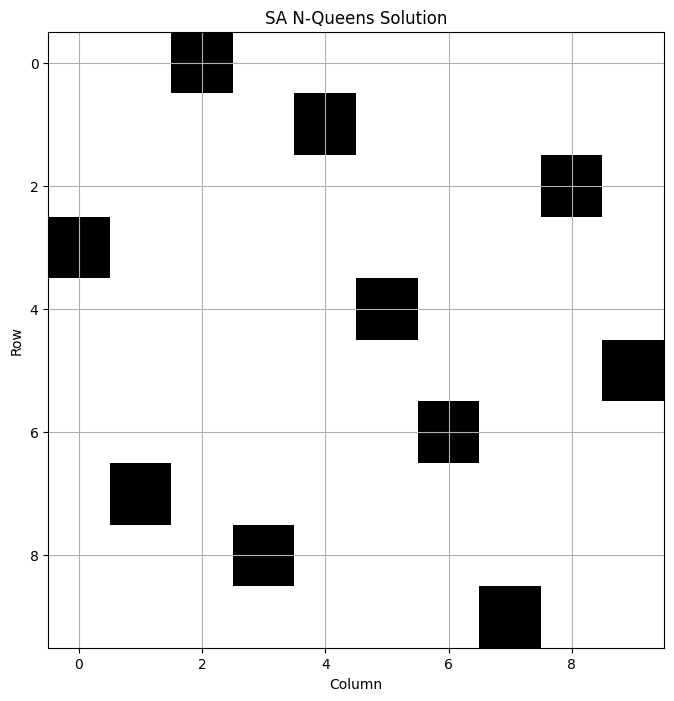

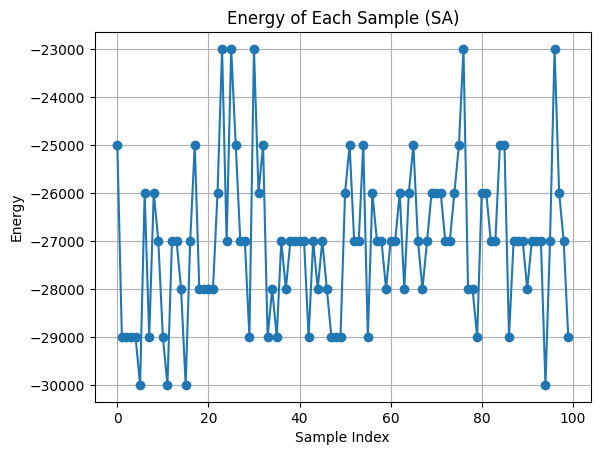

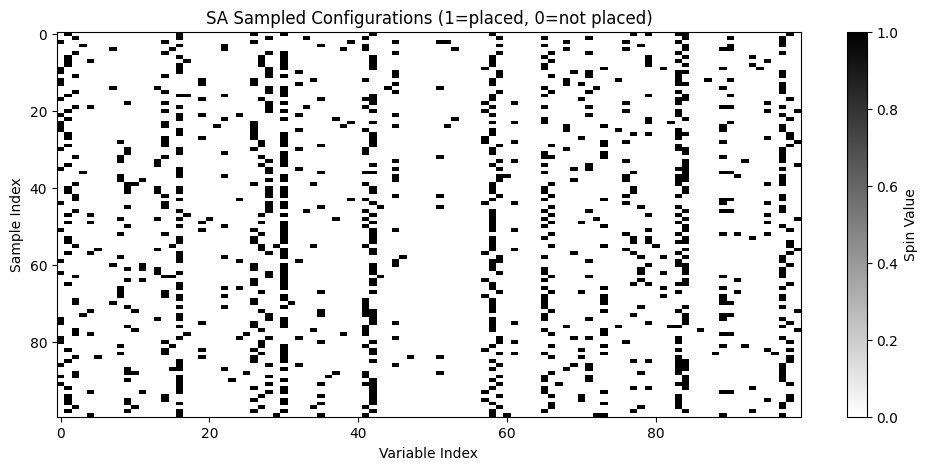

In [ ]:
# Solve using SA
sampler_sa = dimod.SimulatedAnnealingSampler()
sampleset_sa = sampler_sa.sample_qubo(
    Q,
    num_reads=100
)

# Parse the best solution and visualize
best_solution_sa = sampleset_sa.first.sample
solution_matrix_sa = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        k = i * N + j
        if best_solution_sa.get(k) == 1:
            solution_matrix_sa[i, j] = 1

print("--- SA Solution ---")
print("Found solution:")
print(solution_matrix_sa)
print(f"Energy: {sampleset_sa.first.energy:.2f}")

# Plot the result
plt.figure(figsize=(8, 8))
plt.imshow(solution_matrix_sa, cmap='binary')
plt.title('SA N-Queens Solution')
plt.xlabel('Column')
plt.ylabel('Row')
plt.grid(True)
plt.show()

# Heatmap: observe all sampled binary configurations
energies = sampleset_sa.record.energy
plt.figure()
plt.plot(energies, marker='o')
plt.title("Energy of Each Sample (SA)")
plt.xlabel("Sample Index")
plt.ylabel("Energy")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.imshow(sampleset_sa.record.sample, aspect='auto', cmap='binary')
plt.xlabel("Variable Index")
plt.ylabel("Sample Index")
plt.title("SA Sampled Configurations (1=placed, 0=not placed)")
plt.colorbar(label="Spin Value")
plt.show()

# Part II: Using Quantum-Inspired Simulated Annealing (SQA) - Time-Slicing Method

SQA is a more advanced algorithm that incorporates the concept of quantum fluctuations on top of SA. On actual quantum hardware, this is realized through a transverse field, allowing the algorithm to “tunnel” through energy barriers with a certain probability, similar to the quantum tunneling effect.

On classical computers, we can simulate this quantum process using the **time-slicing** method. We discretize the entire annealing process into a series of time slices (num_sweeps). In each slice, the simulator recalculates the strength of the transverse field, enabling the algorithm to explore the solution space more flexibly and thus escape local optima more effectively.

--- SQA Solution ---
Found solution:
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Energy: -30000.00


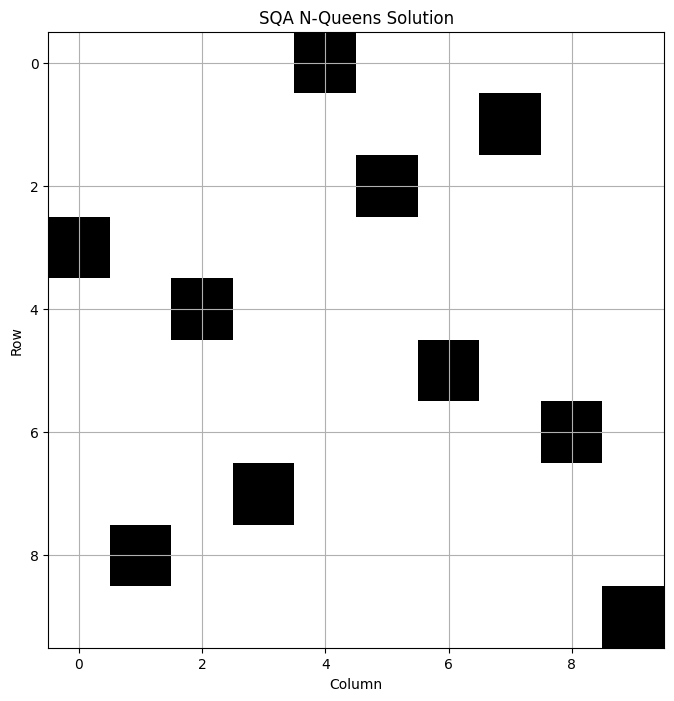

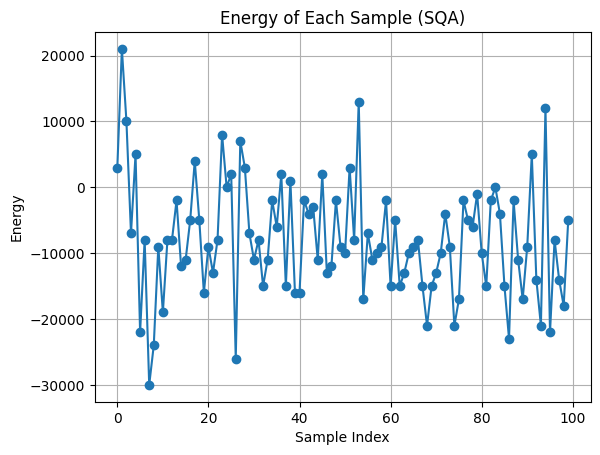

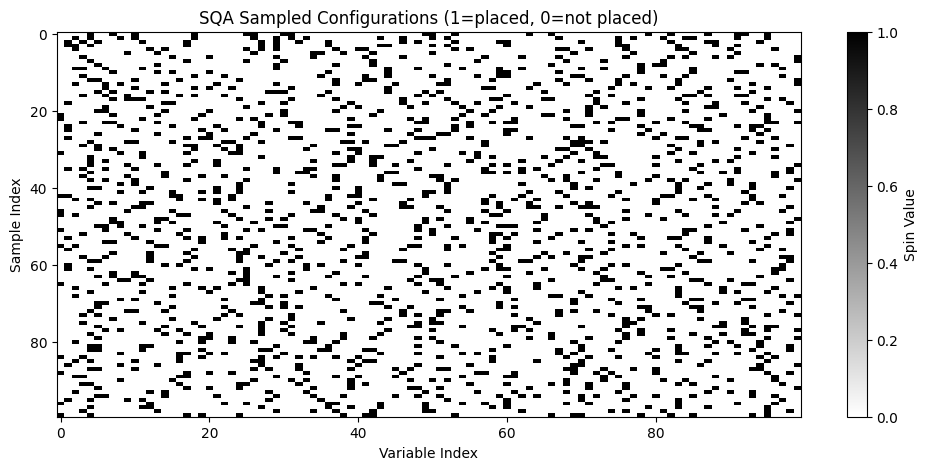

In [ ]:
# 4. Initialize SQA
sampler_sqa = oj.SQASampler()
sampleset_sqa = sampler_sqa.sample_qubo(
    Q,
    num_reads=100,
    num_sweeps=2000,
)

# Parse the best solution and visualize
best_solution_sqa = sampleset_sqa.first.sample
solution_matrix_sqa = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        k = i * N + j
        if best_solution_sqa.get(k) == 1:
            solution_matrix_sqa[i, j] = 1

print("--- SQA Solution ---")
print("Found solution:")
print(solution_matrix_sqa)
print(f"Energy: {sampleset_sqa.first.energy:.2f}")

# Plot the result
plt.figure(figsize=(8, 8))
plt.imshow(solution_matrix_sqa, cmap='binary')
plt.title('SQA N-Queens Solution')
plt.xlabel('Column')
plt.ylabel('Row')
plt.grid(True)
plt.show()

# Heatmap: observe all sampled binary configurations
energies_sqa = sampleset_sqa.record.energy
plt.figure()
plt.plot(energies_sqa, marker='o')
plt.title("Energy of Each Sample (SQA)")
plt.xlabel("Sample Index")
plt.ylabel("Energy")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.imshow(sampleset_sqa.record.sample, aspect='auto', cmap='binary')
plt.xlabel("Variable Index")
plt.ylabel("Sample Index")
plt.title("SQA Sampled Configurations (1=placed, 0=not placed)")
plt.colorbar(label="Spin Value")
plt.show()

1. Comparison and Analysis

Compare the final layouts found by SA and SQA. Are their results the same? If they are different, which solution has an energy value closer to zero?

In terms of runtime, is there a significant difference between the two? Does this align with your professional expectations and descriptions of these two algorithms?

2. Playing the Strategist

Try adjusting the penalty coefficient penalty. If penalty is set too low, the algorithm may find a conflicting layout, such as placing multiple watchtowers in the same row. Which penalty value do you think best fits your defensive style?

Try adjusting the num_sweeps parameter of SQA. How does increasing or decreasing this value affect the results and the runtime?

3. Quantum Advantage of SQA

Based on your experimental results, what special advantages do you think SQA has over traditional SA in this type of complex layout problem?